# 12 Figure 1 Dataset Overview

Purpose:
This notebook prepares the dataset-level statistics used for Figure 1C and Figure 1D.

Figure 1C:
- mechanism label counts
- structure class counts
- ion type counts
- distribution of log(P_est)

Figure 1D:
- reporting completeness / data availability
- availability of Voc, Jsc, internal resistance, structure, ion/electrolyte, mechanism label, and reported power density

The plots generated here are draft plots for inspection. Final figures will be redrawn in Igor Pro.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Output folder
out_dir = Path("../results/figure1_dataset_overview")
out_dir.mkdir(parents=True, exist_ok=True)

print("Output folder:", out_dir.resolve())

Output folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure1_dataset_overview


In [6]:
data_path = Path("hydrovoltaic_dataset_phase2_input_utf8.csv")

df = pd.read_csv(data_path, encoding="utf-8-sig")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,auxiliary_redox_present,continuous_output,water_interaction_mode,rh_percent,inorganic_electrolyte_present,inorganic_electrolyte_type,inorganic_electrolyte_concentration_wt%,polyelectrolyte_present,active_material_raw,material_class,structure_class,ionic_groups,top_electrode,bottom_electrode,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_Mohm,output_timescale_class,stability_time_min,dominant_mechanism,has_anionic,has_cationic,has_zwitterionic,polyelectrolyte_anionic_raw,polyelectrolyte_cationic_raw,polyelectrolyte_zwitterionic_raw,has_any_polyelectrolyte,estimated_power_density_uW_cm2,log_estimated_power_density,ion_type,asym_env,asym_chem,asym_electrode,mechanism_simple,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,60.0,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,0,0,0,NaN,NaN,NaN,0,0.003750,-2.425853,proton,1,0,0,streaming,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,0,1,evaporation_driven,62.0,0,NaN,NaN,0,ZnO,metal oxide,porous,hydroxyl,Al,Al,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,0,0,0,NaN,NaN,NaN,0,0.002000,-2.698753,anion,1,0,0,streaming,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,lanthanum iron perovskite oxide,semiconductor,porous,hydroxyl,CNT,CNT,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,0,0,0,NaN,NaN,NaN,0,0.009375,-2.027982,anion,1,1,0,streaming,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,0,0,0,NaN,NaN,NaN,0,0.007820,-2.106738,proton,1,0,0,streaming,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,55.0,0,NaN,NaN,0,carbonized rice husk,carbon,porous,"carboxyl, hydroxyl, silanol",CNT,CNT,1,0.0,0.16,0.0400,NaN,NaN,hours,600.0,streaming,0,0,0,NaN,NaN,NaN,0,0.001600,-2.795609,proton,1,0,0,streaming,1,0,0,NaN,0


In [3]:
# Load dataset
# Change this filename if your final phase-2 input file has a slightly different name
data_path = Path("hydrovoltaic_dataset_phase2_input_utf8.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,auxiliary_redox_present,continuous_output,water_interaction_mode,rh_percent,inorganic_electrolyte_present,inorganic_electrolyte_type,inorganic_electrolyte_concentration_wt%,polyelectrolyte_present,active_material_raw,material_class,structure_class,ionic_groups,top_electrode,bottom_electrode,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_Mohm,output_timescale_class,stability_time_min,dominant_mechanism,has_anionic,has_cationic,has_zwitterionic,polyelectrolyte_anionic_raw,polyelectrolyte_cationic_raw,polyelectrolyte_zwitterionic_raw,has_any_polyelectrolyte,estimated_power_density_uW_cm2,log_estimated_power_density,ion_type,asym_env,asym_chem,asym_electrode,mechanism_simple,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,60.0,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,0,0,0,NaN,NaN,NaN,0,0.003750,-2.425853,proton,1,0,0,streaming,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,0,1,evaporation_driven,62.0,0,NaN,NaN,0,ZnO,metal oxide,porous,hydroxyl,Al,Al,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,0,0,0,NaN,NaN,NaN,0,0.002000,-2.698753,anion,1,0,0,streaming,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,lanthanum iron perovskite oxide,semiconductor,porous,hydroxyl,CNT,CNT,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,0,0,0,NaN,NaN,NaN,0,0.009375,-2.027982,anion,1,1,0,streaming,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,0,0,0,NaN,NaN,NaN,0,0.007820,-2.106738,proton,1,0,0,streaming,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,55.0,0,NaN,NaN,0,carbonized rice husk,carbon,porous,"carboxyl, hydroxyl, silanol",CNT,CNT,1,0.0,0.16,0.0400,NaN,NaN,hours,600.0,streaming,0,0,0,NaN,NaN,NaN,0,0.001600,-2.795609,proton,1,0,0,streaming,1,0,0,NaN,0


In [7]:
print("Columns:")
for c in df.columns:
    print(c)

Columns:
paper_doi
review_covered
ref_year
device_structure
built_in_asymmetry
asymmetry_origin
primary_mobile_ion
secondary_ion_present
secondary_mobile_ion
ion_origin
auxiliary_redox_present
continuous_output
water_interaction_mode
rh_percent
inorganic_electrolyte_present
inorganic_electrolyte_type
inorganic_electrolyte_concentration_wt%
polyelectrolyte_present
active_material_raw
material_class
structure_class
ionic_groups
top_electrode
bottom_electrode
electrode_symmetry
metal_electrode
voc_V
jsc_uA_cm2
power_density_uW_cm2
internal_resistance_Mohm
output_timescale_class
stability_time_min
dominant_mechanism
has_anionic
has_cationic
has_zwitterionic
polyelectrolyte_anionic_raw
polyelectrolyte_cationic_raw
polyelectrolyte_zwitterionic_raw
has_any_polyelectrolyte
estimated_power_density_uW_cm2
log_estimated_power_density
ion_type
asym_env
asym_chem
asym_electrode
mechanism_simple
ion_from_material
ion_from_electrolyte
ion_from_water
log_internal_resistance_Mohm
has_internal_resistanc

In [8]:
key_cols = [
    "mechanism_simple",
    "structure_class",
    "ion_type",
    "log_estimated_power_density",
    "estimated_power_density_uW_cm2",
    "voc_V",
    "jsc_uA_cm2",
    "power_density_uW_cm2",
    "log_internal_resistance_Mohm",
    "internal_resistance_Mohm",
    "has_internal_resistance",
    "inorganic_electrolyte_present",
    "inorganic_electrolyte_type"
]

for col in key_cols:
    print(f"{col:35s}", col in df.columns)

mechanism_simple                    True
structure_class                     True
ion_type                            True
log_estimated_power_density         True
estimated_power_density_uW_cm2      True
voc_V                               True
jsc_uA_cm2                          True
power_density_uW_cm2                True
log_internal_resistance_Mohm        True
internal_resistance_Mohm            True
has_internal_resistance             True
inorganic_electrolyte_present       True
inorganic_electrolyte_type          True


## Part A — Figure 1C 数据

In [9]:
# Count tables for mechanism / structure / ion
def count_table(df, col, label_name):
    """
    Create a count and percentage table for a categorical variable.
    """
    tmp = (
        df[col]
        .fillna("missing")
        .astype(str)
        .replace({"": "missing", "nan": "missing", "None": "missing"})
        .value_counts()
        .reset_index()
    )
    tmp.columns = [label_name, "count"]
    tmp["percent"] = tmp["count"] / tmp["count"].sum() * 100
    return tmp

mechanism_counts = count_table(df, "mechanism_simple", "mechanism_simple")
structure_counts = count_table(df, "structure_class", "structure_class")
ion_counts = count_table(df, "ion_type", "ion_type")

print("Mechanism counts")
display(mechanism_counts)

print("Structure counts")
display(structure_counts)

print("Ion type counts")
display(ion_counts)

Mechanism counts


,mechanism_simple,count,percent
0,ion_gradient,107,67.295597
1,streaming,52,32.704403


Structure counts


,structure_class,count,percent
0,porous,118,74.213836
1,film,22,13.836478
2,hydrogel,14,8.805031
3,hydrogel + porous,4,2.515723
4,hydrogel + film,1,0.628931


Ion type counts


,ion_type,count,percent
0,proton,96,60.377358
1,other_cation,54,33.962264
2,anion,9,5.660377


In [10]:
# Target distribution data
target_col = "log_estimated_power_density"

target_df = df[[target_col]].dropna().copy()
target_df = target_df.rename(columns={target_col: "log_P_est"})

print("Target count:", len(target_df))
display(target_df.describe())

Target count: 159


,log_P_est
count,159.000000
mean,-0.380143
std,1.324738
min,-4.283997
25%,-1.243577
50%,-0.281913
75%,0.559267
max,2.916454


In [11]:
# Histogram bin data for Igor 这个不是必须，但给 Igor 很方便。
# Histogram data for log(P_est)
hist_counts, bin_edges = np.histogram(target_df["log_P_est"], bins=15)

hist_df = pd.DataFrame({
    "bin_left": bin_edges[:-1],
    "bin_right": bin_edges[1:],
    "bin_center": (bin_edges[:-1] + bin_edges[1:]) / 2,
    "count": hist_counts
})

display(hist_df)


,bin_left,bin_right,bin_center,count
0,-4.283997,-3.803967,-4.043982,1
1,-3.803967,-3.323937,-3.563952,1
2,-3.323937,-2.843907,-3.083922,4
3,-2.843907,-2.363876,-2.603892,5
4,-2.363876,-1.883846,-2.123861,11
5,-1.883846,-1.403816,-1.643831,11
6,-1.403816,-0.923786,-1.163801,26
7,-0.923786,-0.443756,-0.683771,14
8,-0.443756,0.036274,-0.203741,19
9,0.036274,0.516304,0.276289,26


In [12]:
# Export Figure 1C CSV files
mechanism_counts.to_csv(out_dir / "fig1C_mechanism_counts.csv", index=False, encoding="utf-8-sig")
structure_counts.to_csv(out_dir / "fig1C_structure_counts.csv", index=False, encoding="utf-8-sig")
ion_counts.to_csv(out_dir / "fig1C_ion_type_counts.csv", index=False, encoding="utf-8-sig")
target_df.to_csv(out_dir / "fig1C_log_P_est_raw.csv", index=False, encoding="utf-8-sig")
hist_df.to_csv(out_dir / "fig1C_log_P_est_histogram_bins.csv", index=False, encoding="utf-8-sig")

print("Figure 1C CSV files exported to:")
print(out_dir.resolve())

Figure 1C CSV files exported to:
C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure1_dataset_overview


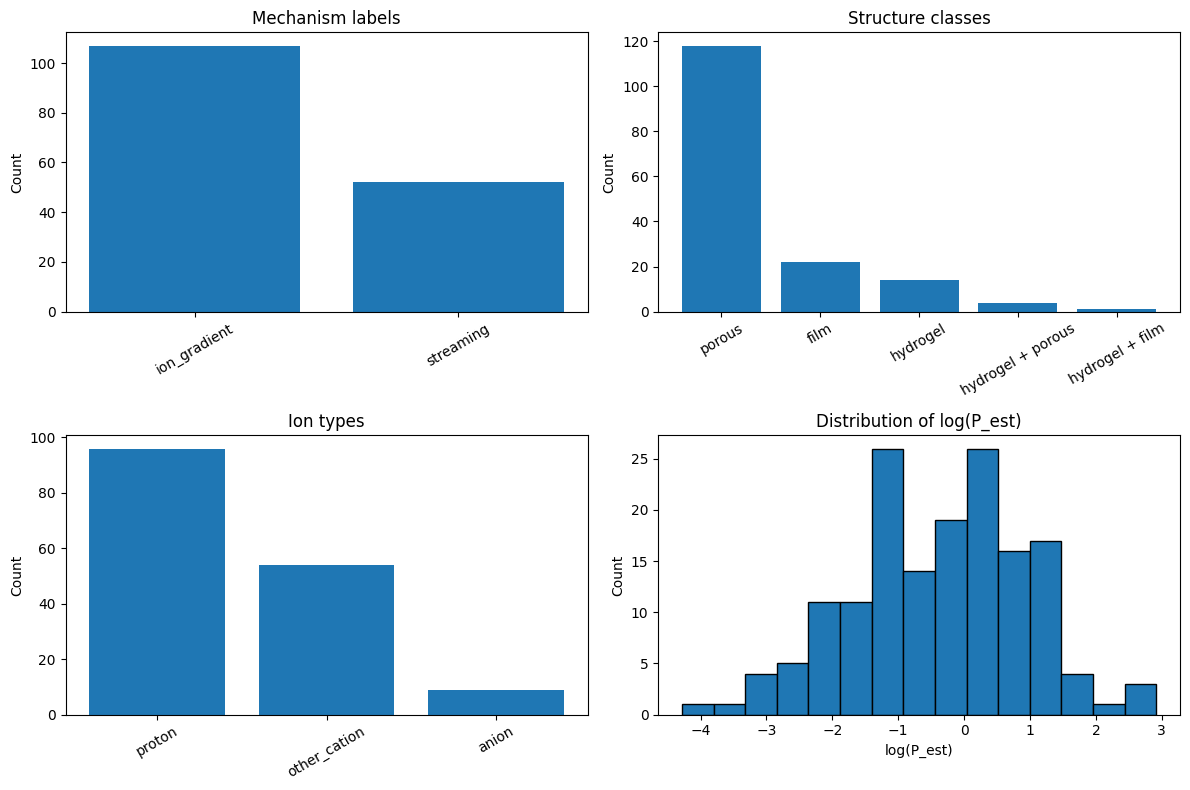

In [13]:
# Draft plot for Figure 1C

# 这个只是 notebook 里检查用，最后你用 Igor 重画。
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Mechanism counts
axes[0, 0].bar(mechanism_counts["mechanism_simple"], mechanism_counts["count"])
axes[0, 0].set_title("Mechanism labels")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=30)

# Structure counts
axes[0, 1].bar(structure_counts["structure_class"], structure_counts["count"])
axes[0, 1].set_title("Structure classes")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis="x", rotation=30)

# Ion type counts
axes[1, 0].bar(ion_counts["ion_type"], ion_counts["count"])
axes[1, 0].set_title("Ion types")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis="x", rotation=30)

# Target distribution
axes[1, 1].hist(target_df["log_P_est"], bins=15, edgecolor="black")
axes[1, 1].set_title("Distribution of log(P_est)")
axes[1, 1].set_xlabel("log(P_est)")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Part B — Figure 1D 数据

In [14]:
# Define availability function
def is_available(series):
    """
    Define availability for literature-extracted values.
    Treat NaN, empty strings, and common missing labels as unavailable.
    Numeric zero is treated as available, because zero may be a valid encoded value.
    """
    s = series.copy()
    
    if s.dtype == "O":
        s = s.astype(str).str.strip()
        missing_like = ["", "nan", "none", "None", "NaN", "NA", "N/A", "not reported", "missing", "-"]
        return ~s.isin(missing_like)
    else:
        return s.notna()

In [15]:
# Choose variables for reporting completeness

# 这里我用你现在数据里的实际列名。internal resistance 有时列名会变，所以写得稳一点。
# Identify internal resistance column
possible_R_cols = [
    "internal_resistance_Mohm",
    "internal_resistance_MΩ",
    "log_internal_resistance_Mohm",
    "has_internal_resistance"
]

R_col = None
for c in possible_R_cols:
    if c in df.columns:
        R_col = c
        break

print("Internal resistance column used:", R_col)

Internal resistance column used: internal_resistance_Mohm


In [16]:
# 然后定义 Figure 1D 的变量：
availability_items = {
    "Voc": ["voc_V"],
    "Jsc": ["jsc_uA_cm2"],
    "Reported power density": ["power_density_uW_cm2"],
    "Internal resistance": [R_col] if R_col is not None else [],
    "Structure": ["structure_class"],
    "Ion type": ["ion_type"],
    "Electrolyte descriptor": ["inorganic_electrolyte_present", "inorganic_electrolyte_type"],
    "Mechanism label": ["mechanism_simple"]
}

In [17]:
# Compute availability table
availability_rows = []

n_total = len(df)

for item, cols in availability_items.items():
    cols = [c for c in cols if c in df.columns]
    
    if len(cols) == 0:
        n_available = 0
        note = "column not found"
    elif len(cols) == 1:
        mask = is_available(df[cols[0]])
        n_available = mask.sum()
        note = cols[0]
    else:
        # available if any of the related columns is available
        masks = [is_available(df[c]) for c in cols]
        combined_mask = np.logical_or.reduce(masks)
        n_available = combined_mask.sum()
        note = " OR ".join(cols)
    
    availability_rows.append({
        "variable_group": item,
        "columns_used": note,
        "n_available": int(n_available),
        "n_total": int(n_total),
        "availability_percent": n_available / n_total * 100
    })

availability_df = pd.DataFrame(availability_rows)

display(availability_df)

,variable_group,columns_used,n_available,n_total,availability_percent
0,Voc,voc_V,159,159,100.000000
1,Jsc,jsc_uA_cm2,159,159,100.000000
2,Reported power density,power_density_uW_cm2,108,159,67.924528
3,Internal resistance,internal_resistance_Mohm,112,159,70.440252
4,Structure,structure_class,159,159,100.000000
5,Ion type,ion_type,159,159,100.000000
6,Electrolyte descriptor,inorganic_electrolyte_present OR inorganic_ele...,159,159,100.000000
7,Mechanism label,mechanism_simple,159,159,100.000000


In [18]:
# Export Figure 1D CSV
availability_df.to_csv(
    out_dir / "fig1D_reporting_completeness.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Figure 1D availability table exported:")
print(out_dir / "fig1D_reporting_completeness.csv")

Figure 1D availability table exported:
..\results\figure1_dataset_overview\fig1D_reporting_completeness.csv


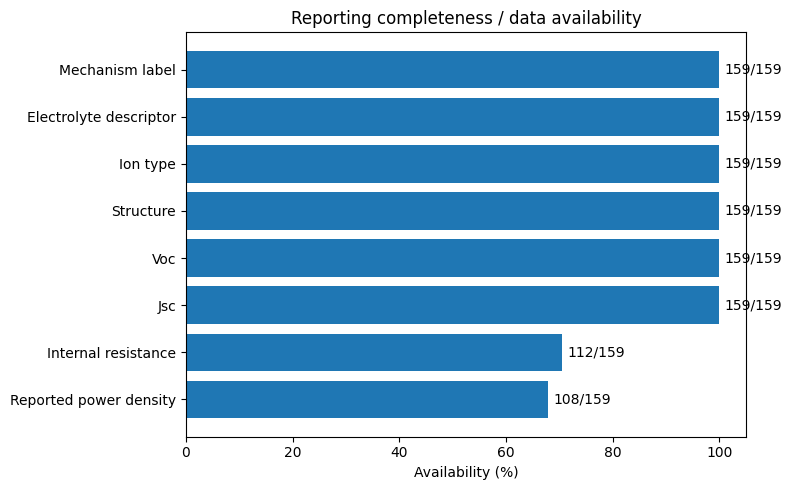

In [19]:
# Draft plot for Figure 1D
availability_plot_df = availability_df.sort_values("availability_percent", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    availability_plot_df["variable_group"],
    availability_plot_df["availability_percent"]
)

plt.xlabel("Availability (%)")
plt.title("Reporting completeness / data availability")
plt.xlim(0, 105)

for i, row in enumerate(availability_plot_df.itertuples()):
    plt.text(
        row.availability_percent + 1,
        i,
        f"{row.n_available}/{row.n_total}",
        va="center"
    )

plt.tight_layout()
plt.show()

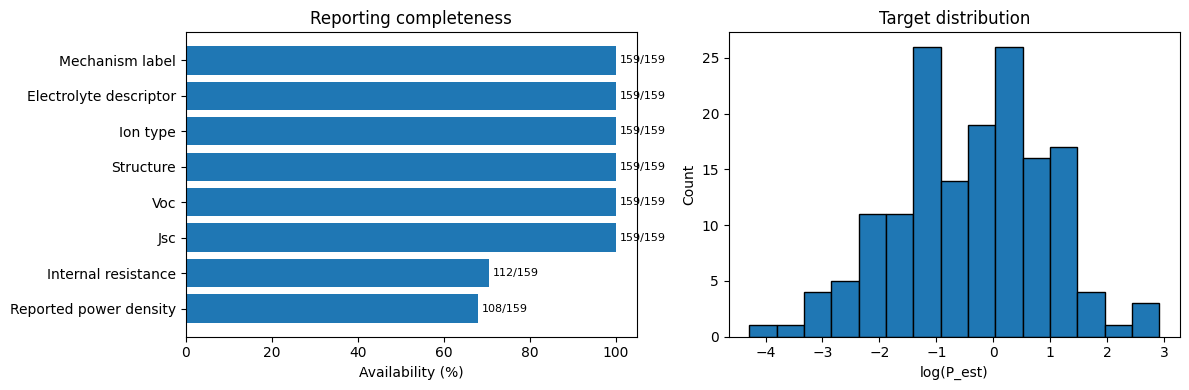

In [20]:
# Optional combined draft for Figure 1D

# 如果你想把 availability + log(P_est) distribution 放在一个 panel 里检查：
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Availability
plot_df = availability_df.sort_values("availability_percent", ascending=True)
axes[0].barh(plot_df["variable_group"], plot_df["availability_percent"])
axes[0].set_xlabel("Availability (%)")
axes[0].set_title("Reporting completeness")
axes[0].set_xlim(0, 105)

for i, row in enumerate(plot_df.itertuples()):
    axes[0].text(
        row.availability_percent + 1,
        i,
        f"{row.n_available}/{row.n_total}",
        va="center",
        fontsize=8
    )

# Target distribution
axes[1].hist(target_df["log_P_est"], bins=15, edgecolor="black")
axes[1].set_xlabel("log(P_est)")
axes[1].set_ylabel("Count")
axes[1].set_title("Target distribution")

plt.tight_layout()
plt.show()

## Summary for Figure 1C and Figure 1D

Figure 1C summarizes the composition of the curated hydrovoltaic dataset, including mechanism labels, structure classes, ion types, and the distribution of the log-transformed estimated power-density target.

Figure 1D summarizes reporting completeness for key literature-extracted variables. The availability plot highlights the heterogeneity of hydrovoltaic reporting and supports the need for standardized target construction and descriptor-based analysis.

All CSV files for Igor Pro redrawing were exported to:
`../results/figure1_dataset_overview/`